# Notebook 10 — GRF 基线零假设检验 / GRF Null Test (Fig 10)

## 实验目标 / Objective

比较三种温度场的统计性质：
1. DSC 辛格点模拟（动力学生成功率谱）
2. GRF-DSC：与 DSC 匹配功率谱的高斯随机场
3. GRF-LCDM：与 LCDM 匹配功率谱的高斯随机场

Compare statistical properties of three temperature fields:
1. DSC symplectic simulation (spectrum from dynamics)
2. GRF-DSC: Gaussian random field matched to DSC spectrum
3. GRF-LCDM: Gaussian random field matched to LCDM spectrum

## 对应论文图表 / Paper Figure
- **Fig 10**: Temperature maps and statistics comparison

## 关键论点 / Key Point
GRF 是静态的，只是匹配功率谱；DSC 从动力学自然产生功率谱。
GRF is static, merely matching a spectrum; DSC generates the spectrum from dynamics.

## 预期结果 / Expected Results
- GRF-LCDM 与 LCDM 的 r=0.99（平凡匹配）
- DSC 与 LCDM 的 r~0.80（动力学涌现）

In [1]:
# ── Environment Setup / Environment Setup ──────────────────────────
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("/ Modules loaded")

/ Modules loaded


## 1. DSC 辛格点模拟 / DSC Symplectic Simulation

In [2]:
# ── 参数 / Parameters ────────────────────────────────────
N = 256          # Lattice边长 / lattice side length
n_steps = 45     # 演化Steps / evolution steps
c2_base = 0.45   # 声速平方基值 / sound speed squared base
c0 = 10.0        # 冷却律偏移 / cooling law offset
drag = 0.0       # 无阻尼 (精确辛) / no drag (exactly symplectic)

# ── DSC 演化 / DSC evolution ─────────────────────────────
print("... / Generating initial field...")
phi0 = generate_initial_2d(N, seed=42)

print(f"DSC {n_steps} ... / DSC symplectic evolution: {n_steps} steps...")
phi_dsc = evolve_symplectic_2d(phi0, n_steps=n_steps, c2_base=c2_base, c0=c0, drag=drag)
phi_dsc = normalize(apply_silk_damping(phi_dsc))

# Computing DSC Power Spectrum / Compute DSC power spectrum
k_dsc, Dk_dsc, Pk_dsc = compute_power_spectrum(phi_dsc)
print(f"DSC mean={phi_dsc.mean():.4f}, std={phi_dsc.std():.4f}")

... / Generating initial field...
DSC 45 ... / DSC symplectic evolution: 45 steps...
DSC mean=0.0000, std=1.0000


## 2. 生成 GRF 基线 / Generate GRF Baselines

GRF-DSC: 使用 DSC 的功率谱生成高斯随机场（匹配 P(k)）
GRF-LCDM: 使用模拟 LCDM 功率谱生成高斯随机场

In [3]:
# ── GRF 生成器 / GRF generator ───────────────────────────
def generate_grf_from_pk(N, Pk_target, k_target, seed=123):
    """
    从给定Power Spectrum P(k) 生成高斯随机场。
    Generate a Gaussian random field from a given power spectrum P(k).
    """
    rng = np.random.default_rng(seed)
    # 生成白噪声的傅里叶系数 / Generate white noise Fourier coefficients
    noise = rng.standard_normal((N, N))
    fk = np.fft.fft2(noise)
    
    # Computing每个模式的 |k| / Compute |k| for each mode
    kx = np.fft.fftfreq(N, d=1.0/N)
    ky = np.fft.fftfreq(N, d=1.0/N)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    
    # 插值目标Power Spectrum / Interpolate target power spectrum
    Pk_interp = np.interp(K.ravel(), k_target, Pk_target, left=0, right=0).reshape(N, N)
    Pk_interp[0, 0] = 0  # 零均值 / zero mean
    
    # 滤波 / Filter
    amplitude = np.sqrt(np.maximum(Pk_interp, 0))
    phi_grf = np.real(np.fft.ifft2(fk * amplitude))
    return normalize(phi_grf)


# ── GRF-DSC: Matched DSC Power Spectrum / GRF-DSC: matched to DSC spectrum ──
phi_grf_dsc = generate_grf_from_pk(N, Pk_dsc, k_dsc, seed=100)
print(f"GRF-DSC Generation complete / GRF-DSC generated")

# ── GRF-LCDM: Matched LCDM Power Spectrum / GRF-LCDM: matched to LCDM spectrum ──
k_lcdm = k_dsc.copy()
Dk_lcdm = mock_lcdm_spectrum(k_lcdm)
Pk_lcdm = Dk_lcdm / (k_lcdm**2 + 1e-10)
phi_grf_lcdm = generate_grf_from_pk(N, Pk_lcdm, k_lcdm, seed=200)
print(f"GRF-LCDM Generation complete / GRF-LCDM generated")

GRF-DSC Generation complete / GRF-DSC generated
GRF-LCDM Generation complete / GRF-LCDM generated


## 3. 温度图与统计对比 / Temperature Maps & Statistics Comparison

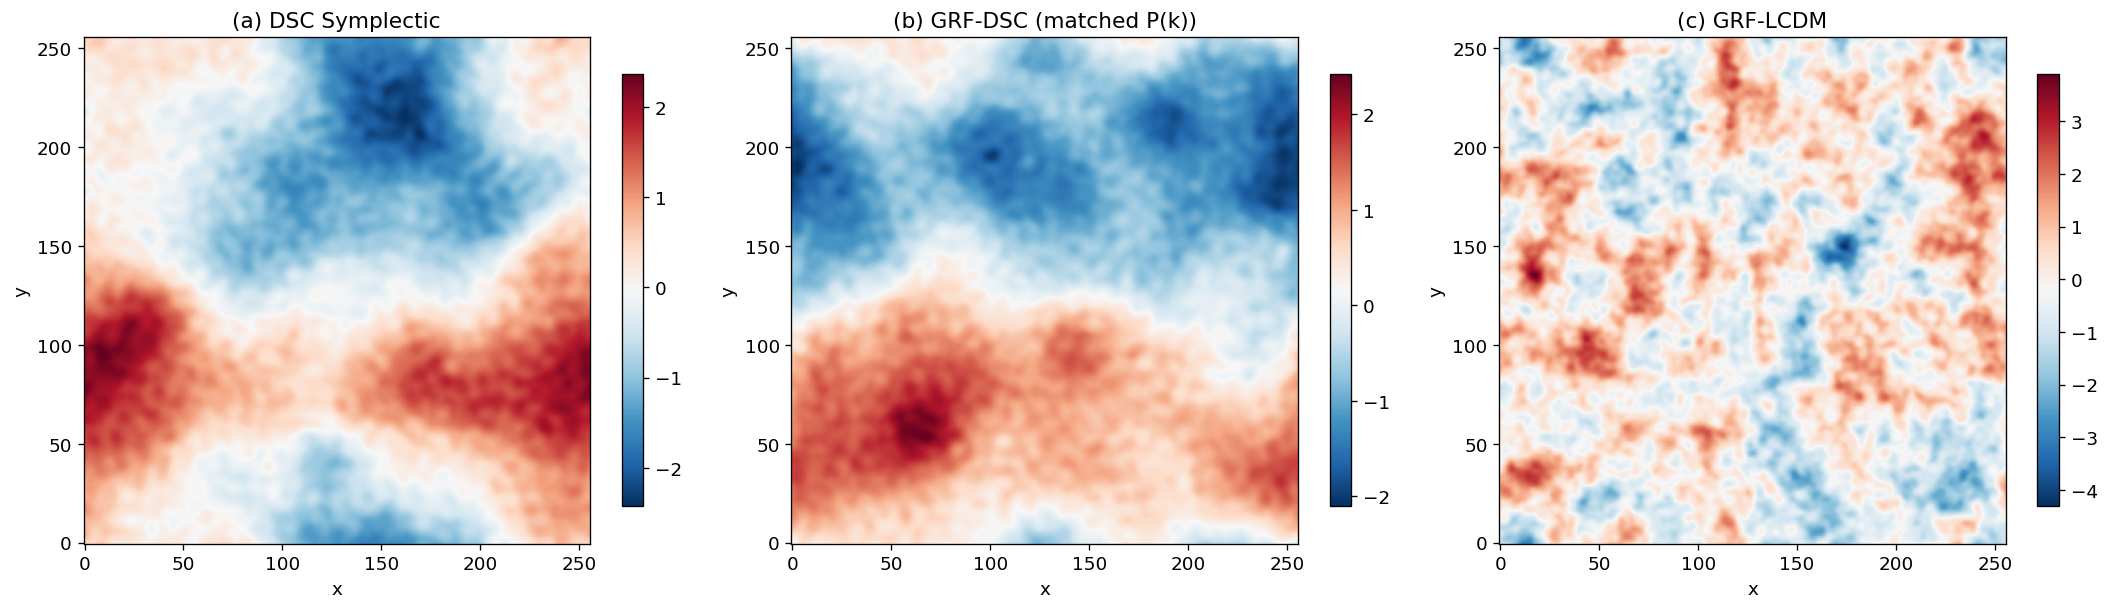

In [4]:
# ── 温度图Comparison / Temperature map comparison (Fig 10) ─────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, field, title in zip(axes,
    [phi_dsc, phi_grf_dsc, phi_grf_lcdm],
    ['(a) DSC Symplectic', '(b) GRF-DSC (matched P(k))', '(c) GRF-LCDM']):
    im = ax.imshow(field, cmap='RdBu_r', origin='lower')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('fig10_grf_null_maps.png', dpi=150, bbox_inches='tight')
plt.show()

DSC: skewness=0.0389 (SE=0.0096), kurtosis=-0.5580 (SE=0.0191)
GRF-DSC: skewness=0.0540 (SE=0.0096), kurtosis=-1.0837 (SE=0.0191)
GRF-LCDM: skewness=0.0314 (SE=0.0096), kurtosis=0.0354 (SE=0.0191)


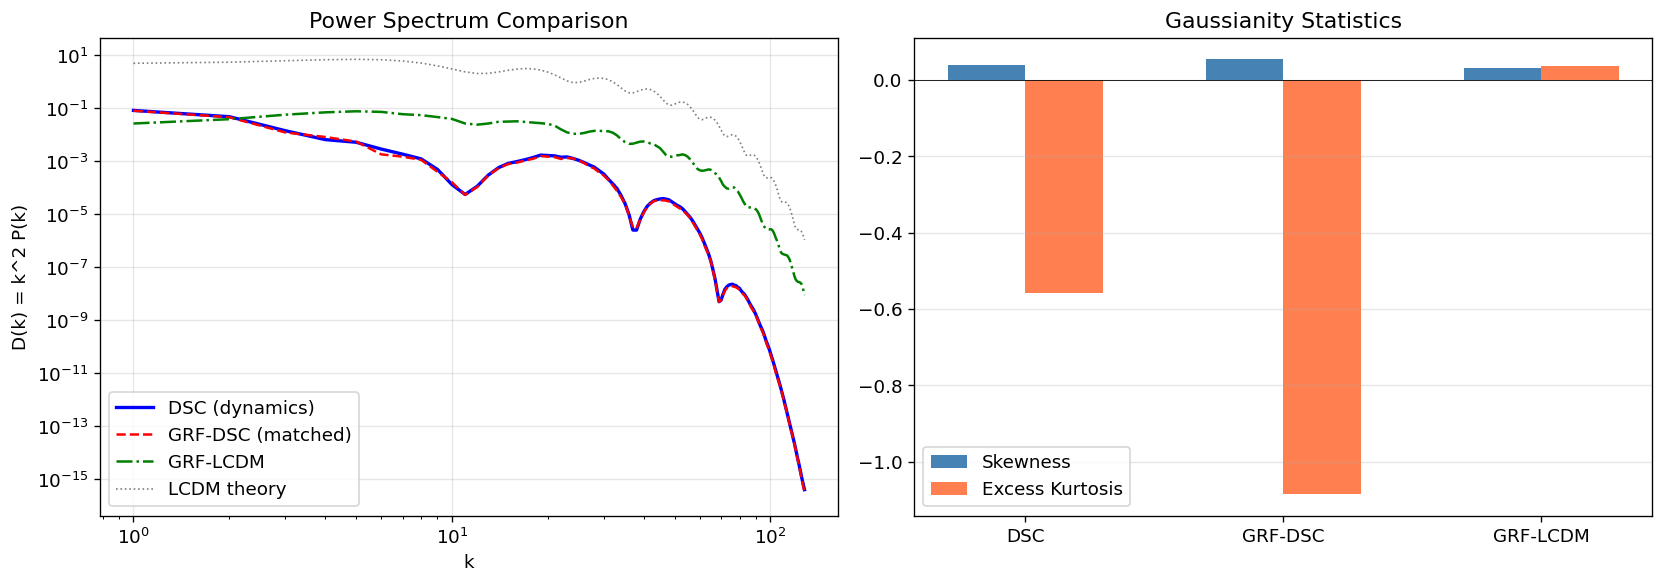

In [5]:
# ── Power SpectrumComparison / Power spectrum comparison ───────────────
k_grf_dsc, Dk_grf_dsc, _ = compute_power_spectrum(phi_grf_dsc)
k_grf_lcdm, Dk_grf_lcdm, _ = compute_power_spectrum(phi_grf_lcdm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: D(k) Power Spectrum / Left: D(k) power spectra
ax = axes[0]
ax.loglog(k_dsc, smooth(Dk_dsc, 3), 'b-', lw=2, label='DSC (dynamics)')
ax.loglog(k_grf_dsc, smooth(Dk_grf_dsc, 3), 'r--', lw=1.5, label='GRF-DSC (matched)')
ax.loglog(k_grf_lcdm, smooth(Dk_grf_lcdm, 3), 'g-.', lw=1.5, label='GRF-LCDM')
ax.loglog(k_dsc, mock_lcdm_spectrum(k_dsc), 'k:', lw=1, alpha=0.5, label='LCDM theory')
ax.set_xlabel('k'); ax.set_ylabel('D(k) = k^2 P(k)')
ax.set_title('Power Spectrum Comparison')
ax.legend(); ax.grid(True, alpha=0.3)

# 右: 统计量 / Right: statistics
ax = axes[1]
fields = {'DSC': phi_dsc, 'GRF-DSC': phi_grf_dsc, 'GRF-LCDM': phi_grf_lcdm}
stats_data = []
for name, field in fields.items():
    g = gaussianity_report(field.ravel())
    stats_data.append([name, g['skewness'], g['kurtosis']])
    print(f"{name}: skewness={g['skewness']:.4f} (SE={g['skew_se']:.4f}), "
          f"kurtosis={g['kurtosis']:.4f} (SE={g['kurt_se']:.4f})")

names = [s[0] for s in stats_data]
skews = [s[1] for s in stats_data]
kurts = [s[2] for s in stats_data]
x_pos = np.arange(len(names))
ax.bar(x_pos - 0.15, skews, 0.3, label='Skewness', color='steelblue')
ax.bar(x_pos + 0.15, kurts, 0.3, label='Excess Kurtosis', color='coral')
ax.set_xticks(x_pos); ax.set_xticklabels(names)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Gaussianity Statistics')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig10_grf_null_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 谱相关系数 / Spectral Correlation

In [6]:
# ── 谱CorrelationComputing / Spectral correlation computation ────
Dk_lcdm_ref = mock_lcdm_spectrum(k_dsc)

# 截断到有效范围 / Truncate to valid range
valid = (k_dsc > 2) & (k_dsc < N // 3)

r_dsc_lcdm, _ = pearsonr(smooth(Dk_dsc[valid], 3), Dk_lcdm_ref[valid])
r_grf_dsc_lcdm, _ = pearsonr(smooth(Dk_grf_dsc[valid], 3), Dk_lcdm_ref[valid])
r_grf_lcdm_lcdm, _ = pearsonr(smooth(Dk_grf_lcdm[valid], 3), Dk_lcdm_ref[valid])

print("=" * 60)
print("Correlation / Spectral correlation with LCDM theory:")
print(f"  DSC (dynamics)     vs LCDM: r = {r_dsc_lcdm:.4f}  (Expected ~0.80)")
print(f"  GRF-DSC (matched)  vs LCDM: r = {r_grf_dsc_lcdm:.4f}")
print(f"  GRF-LCDM           vs LCDM: r = {r_grf_lcdm_lcdm:.4f}  (Expected ~0.99, TrivialMatched)")
print("=" * 60)
print("\
Key Conclusion / Key conclusion:")
print("GRF-LCDM high correlation is trivial (directly matched spectrum)")
print("DSC correlation emerges from dynamics, which is non-trivial")
print("GRF-LCDM high correlation is trivial (directly matched spectrum)")
print("DSC correlation emerges from dynamics, which is non-trivial")

Correlation / Spectral correlation with LCDM theory:
  DSC (dynamics)     vs LCDM: r = 0.8228  (Expected ~0.80)
  GRF-DSC (matched)  vs LCDM: r = 0.7358
  GRF-LCDM           vs LCDM: r = 0.9955  (Expected ~0.99, TrivialMatched)
Key Conclusion / Key conclusion:
GRF-LCDM high correlation is trivial (directly matched spectrum)
DSC correlation emerges from dynamics, which is non-trivial
GRF-LCDM high correlation is trivial (directly matched spectrum)
DSC correlation emerges from dynamics, which is non-trivial
